In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Loading Dataset
df = pd.read_excel("/content/ANALYSIS 4.xlsx")


cols = [
    'LOG NIFTY',
    'LOG S&P500',
    'INDIAVIX',
    'LOG CRUDE OIL',
    'LOG US DOLLAR',
    'NET FII',
    'NET DII',
    'NET EXCHANGE',
    'REPO RATE',
    'LOG GDP'
]

data = df[cols].dropna()

# Correlation Matrix
corr_matrix = data.corr()

print("\n=== Correlation Matrix ===")
print(corr_matrix)


# Correlation with NIFTY
nifty_corr = corr_matrix['LOG NIFTY'].sort_values(ascending=False)

print("\n=== Correlation with LOG NIFTY ===")
print(nifty_corr)


# VIF Calculation
X = data.drop(columns=['LOG NIFTY'])

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("\n=== VIF (Multicollinearity Check) ===")
print(vif_data)


print("\n=== High Multicollinearity (VIF > 5) ===")
print(vif_data[vif_data["VIF"] > 5])


=== Correlation Matrix ===
               LOG NIFTY  LOG S&P500  INDIAVIX  LOG CRUDE OIL  LOG US DOLLAR  \
LOG NIFTY       1.000000    0.330308 -0.051211       0.186546      -0.118657   
LOG S&P500      0.330308    1.000000 -0.014774       0.320373      -0.209300   
INDIAVIX       -0.051211   -0.014774  1.000000      -0.021662       0.007025   
LOG CRUDE OIL   0.186546    0.320373 -0.021662       1.000000      -0.170582   
LOG US DOLLAR  -0.118657   -0.209300  0.007025      -0.170582       1.000000   
NET FII         0.258841    0.063681 -0.012994       0.044028      -0.043525   
NET DII        -0.088488   -0.021561 -0.102321      -0.017071       0.025442   
NET EXCHANGE   -0.214894   -0.061188  0.032781      -0.039846       0.101874   
REPO RATE      -0.026608   -0.010292 -0.170422      -0.033091       0.017676   
LOG GDP         0.012778    0.017375 -0.594652       0.006931      -0.011199   

                NET FII   NET DII  NET EXCHANGE  REPO RATE   LOG GDP  
LOG NIFTY      0.258

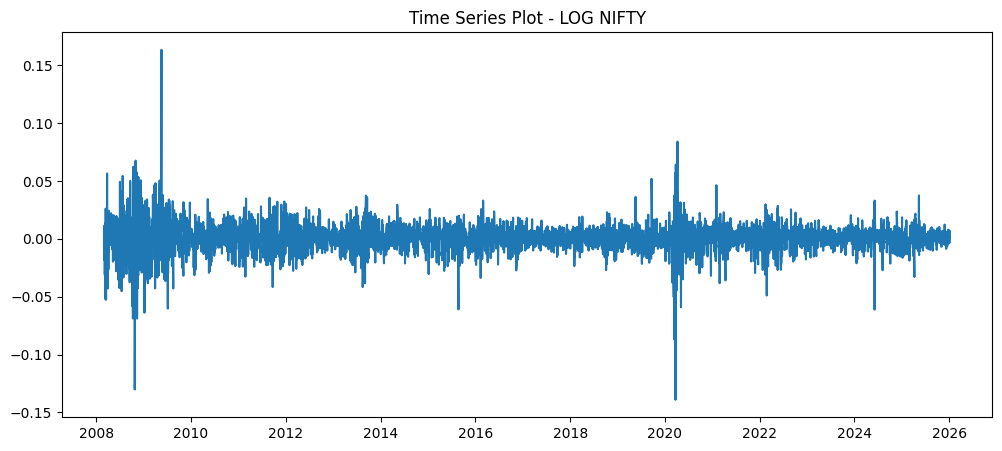

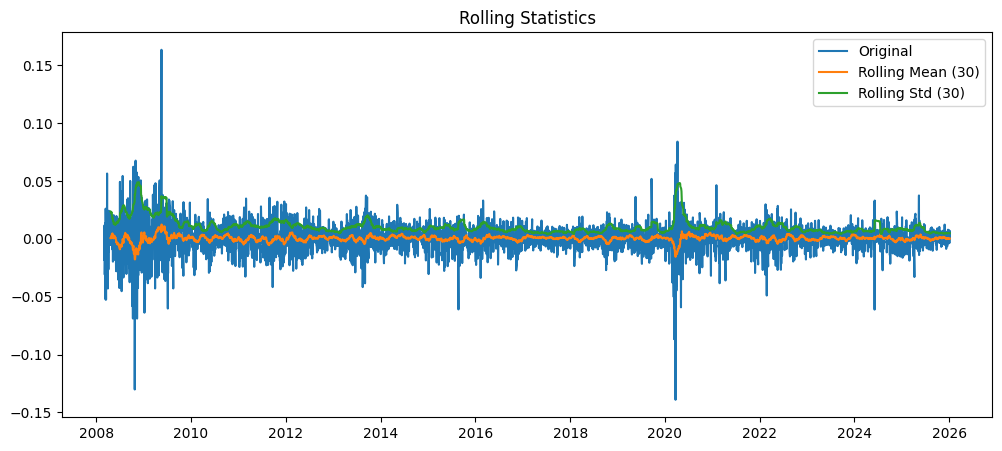

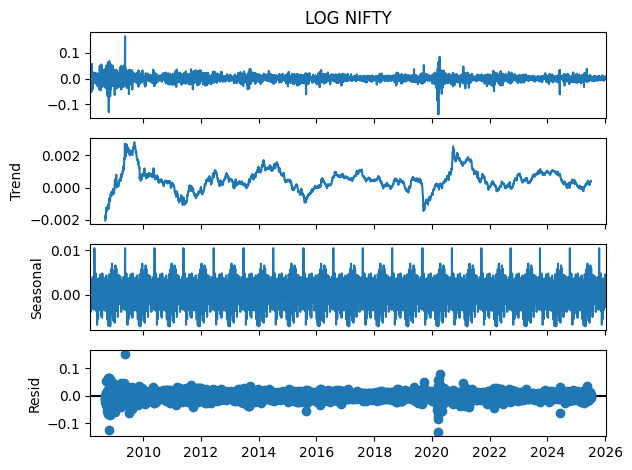

ADF Statistic: -17.754589918630238
p-value: 3.358665759310862e-30
KPSS Statistic: 0.07770808382679188
KPSS p-value: 0.1


/tmp/ipykernel_1847/3152661338.py:71: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


<Figure size 1200x500 with 0 Axes>

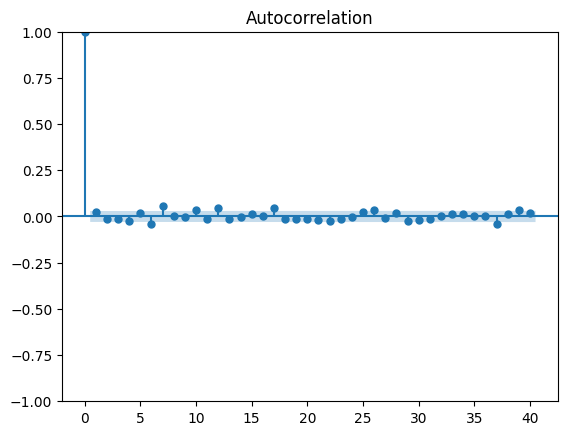

<Figure size 1200x500 with 0 Axes>

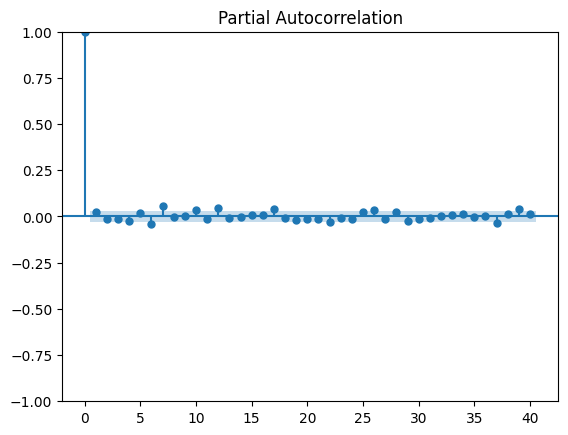

CUSUM Test Statistic: 0.832587402253517
CUSUM p-value: 0.4921439344541088


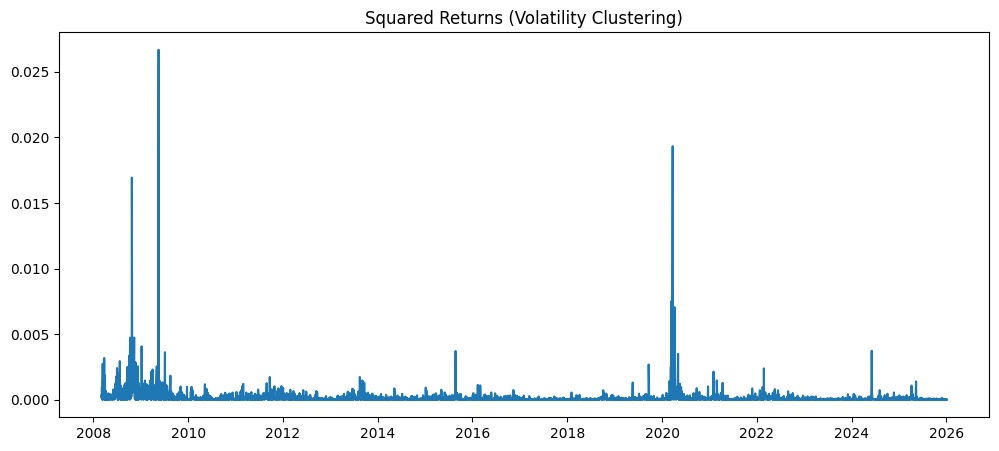

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.tsa.stattools import kpss

# LOADING DATA
df = pd.read_excel("/content/ANALYSIS 4.xlsx")

# Converting Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


df = df.sort_index()

# Choose dependent variable
series = df['LOG NIFTY']


# Plotting Trend
plt.figure(figsize=(12,5))
plt.plot(series)
plt.title("Time Series Plot - LOG NIFTY")
plt.show()


# CHECKING TREND USING ROLLING MEAN
rolling_mean = series.rolling(window=30).mean()
rolling_std = series.rolling(window=30).std()

plt.figure(figsize=(12,5))
plt.plot(series, label='Original')
plt.plot(rolling_mean, label='Rolling Mean (30)')
plt.plot(rolling_std, label='Rolling Std (30)')
plt.legend()
plt.title("Rolling Statistics")
plt.show()


# SEASONAL DECOMPOSITION
decomposition = seasonal_decompose(series, model='additive', period=252)
# 252 = approx trading days in a year

decomposition.plot()
plt.show()


# STATIONARITY TEST

# ADF Test
adf_result = adfuller(series.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# KPSS Test
kpss_result = kpss(series.dropna(), regression='c')
print("KPSS Statistic:", kpss_result[0])
print("KPSS p-value:", kpss_result[1])


# (Seasonality + AR/MA pattern)ACF & PACF
plt.figure(figsize=(12,5))
plot_acf(series.dropna(), lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(series.dropna(), lags=40)
plt.show()


# CUSUM
from statsmodels.api import OLS, add_constant

y = series.dropna()
X = add_constant(np.arange(len(y)))

model = OLS(y, X).fit()
cusum_test = breaks_cusumolsresid(model.resid, ddof=1)

print("CUSUM Test Statistic:", cusum_test[0])
print("CUSUM p-value:", cusum_test[1])


# CHECKING VOLATILITY CLUSTERING
plt.figure(figsize=(12,5))
plt.plot(series**2)
plt.title("Squared Returns (Volatility Clustering)")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.8 MB/s eta 0:00:00
===== ADF TEST =====
ADF Statistic: -17.754589918630238
p-value: 3.358665759310862e-30
----------------------
===== ARIMAX MODEL =====


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:              LOG NIFTY   No. Observations:                 4373
Model:               SARIMAX(1, 0, 1)   Log Likelihood               13454.183
Date:                Fri, 03 Jul 2026   AIC                         -26890.366
Time:                        18:33:57   BIC                         -26832.921
Sample:                             0   HQIC                        -26870.095
                               - 4373                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
LOG S&P500        0.2738      0.009     31.001      0.000       0.256       0.291
LOG CRUDE OIL     0.0404      0.005      7.579      0.000       0.030       0.051
LOG US DOLLAR    -0.0534      0.029     

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001241. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


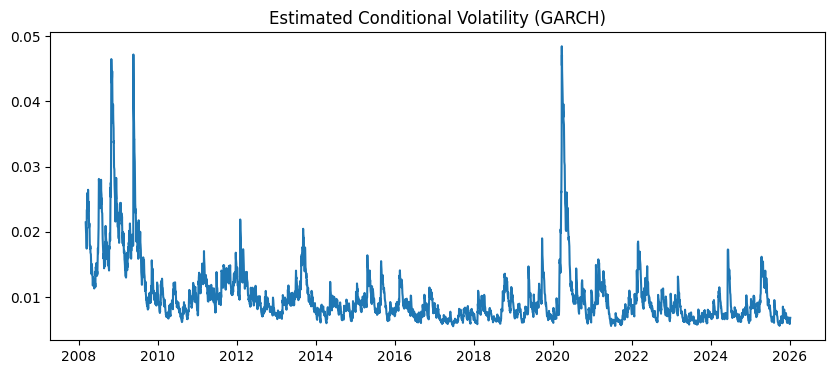

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.stattools import jarque_bera

!pip install arch
from arch import arch_model



df = pd.read_excel("/content/ANALYSIS 4.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.dropna()


# DEFINE VARIABLES
y = df['LOG NIFTY']

X = df[['LOG S&P500',
        'LOG CRUDE OIL',
        'LOG US DOLLAR',
        'NET FII',
        'NET DII',
        'NET EXCHANGE']]



# STATIONARITY CHECK (ADF)
print("===== ADF TEST =====")
adf_result = adfuller(y)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("----------------------")



# FIT ARIMAX MODEL
print("===== ARIMAX MODEL =====")

arimax_model = SARIMAX(y,
                       exog=X,
                       order=(1,0,1),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

arimax_result = arimax_model.fit()

print(arimax_result.summary())



# ARIMAX DIAGNOSTICS
print("\n===== ARIMAX DIAGNOSTICS =====")

# Ljung-Box Test
lb = acorr_ljungbox(arimax_result.resid, lags=[10], return_df=True)
print("\nLjung-Box Test:")
print(lb)

# ARCH Test
arch_test = het_arch(arimax_result.resid)
print("\nARCH Test p-value:", arch_test[1])

# Jarque-Bera Test
jb = jarque_bera(arimax_result.resid)
print("\nJarque-Bera p-value:", jb[1])


# FIT GARCH ON ARIMAX RESIDUALS
print("\n===== ARIMAX + GARCH MODEL =====")

garch_model = arch_model(arimax_result.resid,
                         mean='Zero',
                         vol='GARCH',
                         p=1, q=1,
                         dist='normal')

garch_result = garch_model.fit()

print(garch_result.summary())


# POST-GARCH DIAGNOSTICS
print("\n===== POST-GARCH DIAGNOSTICS =====")

# ARCH test after GARCH
arch_test_garch = het_arch(garch_result.std_resid)
print("Post-GARCH ARCH p-value:", arch_test_garch[1])

# Ljung-Box on standardized residuals
lb_garch = acorr_ljungbox(garch_result.std_resid, lags=[10], return_df=True)
print("\nLjung-Box on Standardized Residuals:")
print(lb_garch)


# MODEL COMPARISON
print("\n===== MODEL COMPARISON =====")
print("ARIMAX AIC:", arimax_result.aic)
print("ARIMAX BIC:", arimax_result.bic)

print("GARCH AIC:", garch_result.aic)
print("GARCH BIC:", garch_result.bic)



# PLOT VOLATILITY
plt.figure(figsize=(10,4))
plt.plot(garch_result.conditional_volatility)
plt.title("Estimated Conditional Volatility (GARCH)")
plt.show()

In [ ]:

# STUDENT-t GARCH MODEL
from arch import arch_model

garch_t_model = arch_model(arimax_result.resid,
                           mean='Zero',
                           vol='GARCH',
                           p=1, q=1,
                           dist='t')

garch_t_result = garch_t_model.fit()

print(garch_t_result.summary())



# POST-GARCH DIAGNOSTICS
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import acorr_ljungbox

# ARCH test after Student-t GARCH
arch_test_t = het_arch(garch_t_result.std_resid)
print("Post Student-t GARCH ARCH p-value:", arch_test_t[1])

# Ljung-Box test
lb_t = acorr_ljungbox(garch_t_result.std_resid, lags=[10], return_df=True)
print(lb_t)



# MODEL COMPARISON
print("\n===== MODEL COMPARISON =====")
print("ARIMAX AIC:", arimax_result.aic)
print("Normal GARCH AIC:", garch_result.aic)
print("Student-t GARCH AIC:", garch_t_result.aic)

Iteration:      1,   Func. Count:      5,   Neg. LLF: -14357.091183083376
Optimization terminated successfully    (Exit mode 0)
            Current function value: -14357.091183082772
            Iterations: 5
            Function evaluations: 5
            Gradient evaluations: 1
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                14357.1
Distribution:      Standardized Student's t   AIC:                          -28706.2
Method:                  Maximum Likelihood   BIC:                          -28680.6
                                              No. Observations:                 4373
Date:                      Fri, Jul 03 2026   Df Residuals:                     4373
Time:                              18:

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001241. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:

# EGARCH MODEL
!pip install arch
from arch import arch_model


import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Loading data
df = pd.read_excel("/content/ANALYSIS 4.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.dropna()


y = df['LOG NIFTY']
X = df[['LOG S&P500',
        'LOG CRUDE OIL',
        'LOG US DOLLAR',
        'NET FII',
        'NET DII',
        'NET EXCHANGE']]

# Fit ARIMAX model
arimax_model = SARIMAX(y,
                       exog=X,
                       order=(1,0,1),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
arimax_result = arimax_model.fit()


egarch_model = arch_model(arimax_result.resid,
                          mean='Zero',
                          vol='EGARCH',
                          p=1, q=1,
                          dist='t')

egarch_result = egarch_model.fit()

print(egarch_result.summary())


# POST-EGARCH DIAGNOSTICS
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import acorr_ljungbox

# ARCH test
arch_test_e = het_arch(egarch_result.std_resid)
print("Post EGARCH ARCH p-value:", arch_test_e[1])

# Ljung Box
lb_e = acorr_ljungbox(egarch_result.std_resid, lags=[10], return_df=True)
print(lb_e)

# Ljung Box on squared residuals
lb_sq = acorr_ljungbox(egarch_result.std_resid**2, lags=[10], return_df=True)
print(lb_sq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001241. Parameter
estimation work better when this value is betwee

Iteration:      1,   Func. Count:      6,   Neg. LLF: 14332.276756807569
Iteration:      2,   Func. Count:     15,   Neg. LLF: 142902.65852278747
Iteration:      3,   Func. Count:     24,   Neg. LLF: -14344.874296628734
Iteration:      4,   Func. Count:     30,   Neg. LLF: -14347.88493297376
Iteration:      5,   Func. Count:     37,   Neg. LLF: -14345.922684443749
Iteration:      6,   Func. Count:     43,   Neg. LLF: -14362.579769833148
Iteration:      7,   Func. Count:     48,   Neg. LLF: -14362.582266718833
Iteration:      8,   Func. Count:     53,   Neg. LLF: -14362.58228858736
Iteration:      9,   Func. Count:     57,   Neg. LLF: -14362.582288587357
Optimization terminated successfully    (Exit mode 0)
            Current function value: -14362.58228858736
            Iterations: 9
            Function evaluations: 57
            Gradient evaluations: 9
                          Zero Mean - EGARCH Model Results                          
Dep. Variable:                         None  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/stat

===== NIFTY 50 PREDICTION TABLE (Actual Prices) =====
            Actual NIFTY  Predicted NIFTY  Lower 95% CI  Upper 95% CI  EGARCH Volatility
Date                                                                                    
2025-11-24      26140.89         26168.40      25859.80      26480.68           0.006052
2025-11-25      26065.67         26417.34      25795.19      27054.50           0.006107
2025-11-26      26388.41         26863.60      25916.42      27845.41           0.006155
2025-11-27      26398.73         26894.50      25632.32      28218.84           0.006210
2025-11-28      26386.04         26822.82      25251.52      28491.88           0.006275
2025-12-01      26358.65         26788.92      24909.55      28810.08           0.006312
2025-12-02      26214.10         26693.30      24513.29      29067.18           0.006357
2025-12-03      26167.58         26642.86      24160.56      29380.21           0.006430
2025-12-04      26215.66         26618.74      23834.91 

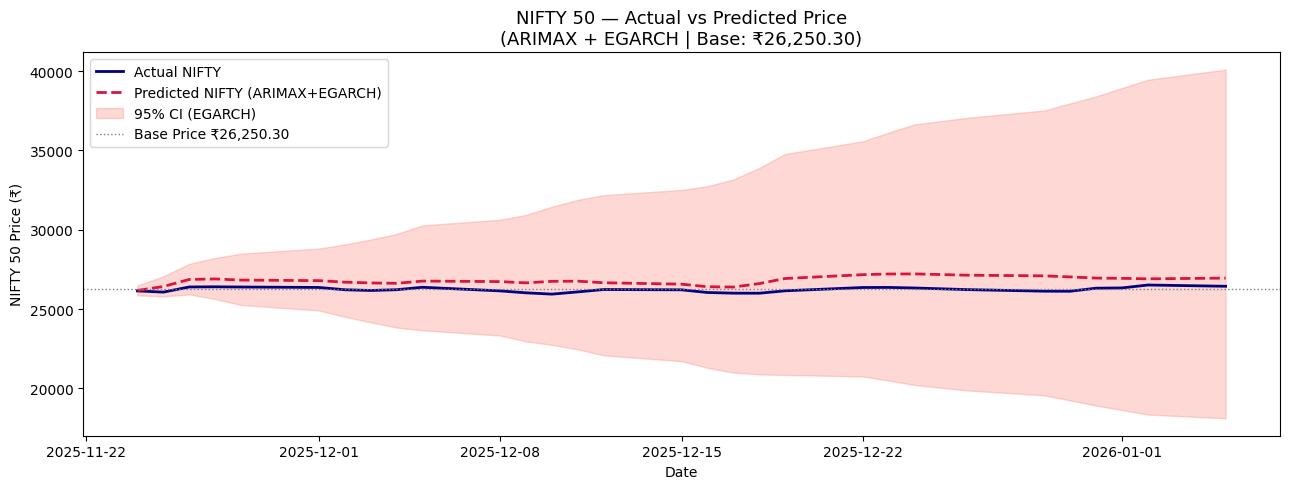

In [ ]:

# CONVERT LOG RETURNS → ACTUAL NIFTY PRICE
# Base price: 26250.30 (closing on 2026-01-05)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


# STEP 0: PREPARE DATA AND FORECAST

# Spliting data into training and testing sets
forecast_horizon = 30 # Number of days to forecast

y_train, y_test = y[:-forecast_horizon], y[-forecast_horizon:]
X_train, X_test = X[:-forecast_horizon], X[-forecast_horizon:]

# Refit ARIMAX model on training data
from statsmodels.tsa.statespace.sarimax import SARIMAX
arimax_model_refit = SARIMAX(y_train,
                               exog=X_train,
                               order=(1,0,1),
                               enforce_stationarity=False,
                               enforce_invertibility=False)
arimax_result_refit = arimax_model_refit.fit()

# Generate ARIMAX forecasts (mean predictions)
arimax_forecast_result = arimax_result_refit.get_forecast(steps=forecast_horizon, exog=X_test)
arimax_forecast = arimax_forecast_result.predicted_mean


from arch import arch_model



egarch_forecast_output = egarch_result.forecast(horizon=forecast_horizon, method='simulation', simulations=1000)
forecast_volatility = np.sqrt(egarch_forecast_output.variance.values[0, :])

# SET BASE PRICE
last_actual_price = 26250.30078   # NIFTY closing on 2026-01-05

# CONVERSION FUNCTION
def log_returns_to_price(log_returns, last_price):
    prices = [last_price]
    for r in log_returns:
        prices.append(prices[-1] * np.exp(r))
    return np.array(prices[1:])

# CONVERT TO ACTUAL PRICES
pred_price   = log_returns_to_price(arimax_forecast.values, last_actual_price)
actual_price = log_returns_to_price(y_test.values,          last_actual_price)

lower_price  = log_returns_to_price(
    arimax_forecast.values - 1.96 * forecast_volatility, last_actual_price)
upper_price  = log_returns_to_price(
    arimax_forecast.values + 1.96 * forecast_volatility, last_actual_price)


# RESULTS TABLE
results_df = pd.DataFrame({
    'Actual NIFTY'     : actual_price.round(2),
    'Predicted NIFTY'  : pred_price.round(2),
    'Lower 95% CI'     : lower_price.round(2),
    'Upper 95% CI'     : upper_price.round(2),
    'EGARCH Volatility': forecast_volatility.round(6)
}, index=y_test.index)

print("===== NIFTY 50 PREDICTION TABLE (Actual Prices) =====")
print(results_df.to_string())


# ACCURACY METRICS
mae  = mean_absolute_error(actual_price, pred_price)
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100

print("\n===== FORECAST ACCURACY (Price Level ₹) =====")
print(f"MAE  : ₹{mae:.2f}")
print(f"RMSE : ₹{rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

#PLOT

plt.figure(figsize=(13, 5))

plt.plot(results_df.index, actual_price,
         color='navy', linewidth=2, label='Actual NIFTY')

plt.plot(results_df.index, pred_price,
         color='crimson', linestyle='--', linewidth=2,
         label='Predicted NIFTY (ARIMAX+EGARCH)')

plt.fill_between(results_df.index,
                 lower_price, upper_price,
                 color='salmon', alpha=0.3, label='95% CI (EGARCH)')

# Annotate base price point
plt.axhline(y=last_actual_price, color='gray',
            linestyle=':', linewidth=1, label=f'Base Price ₹{last_actual_price:,.2f}')

plt.title('NIFTY 50 — Actual vs Predicted Price\n(ARIMAX + EGARCH | Base: ₹26,250.30)',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('NIFTY 50 Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig("nifty_price_prediction.png", dpi=150)
plt.show()